In [32]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

## **1. Data Import and Cleaning:**

### **1.1 Importation des données**

In [33]:
df = pd.read_csv('global_power_plant_database.csv',low_memory=False)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 non-null  float64
 12  owner                           

Notre jeu de données est composé de 34936 échantillons et 36 variables

### **1.2 Valeurs manquantes**

In [35]:
print(df.isnull().sum())

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_gwh_2019               25277


In [36]:
df['other_fuel1'].unique()

array([nan, 'Oil', 'Solar', 'Gas', 'Other', 'Hydro', 'Coal', 'Petcoke',
       'Biomass', 'Waste', 'Cogeneration', 'Storage', 'Wind'],
      dtype=object)

In [37]:
df['other_fuel2'].unique()

array([nan, 'Other', 'Oil', 'Biomass', 'Gas', 'Solar', 'Waste', 'Storage',
       'Hydro', 'Wind', 'Coal', 'Petcoke'], dtype=object)

In [38]:
df['other_fuel3'].unique()

array([nan, 'Other', 'Gas', 'Solar', 'Biomass', 'Hydro', 'Oil', 'Wind',
       'Storage'], dtype=object)

Ici vuee que le nombre de valeurs nulle est nombreuses dans ces trois variables (other_fuel1,other_fuel2, other_fuel3) afin de voir s'ils contiennent les mêmes informations, et vu qu'ils contiennent les mêmes informations, je vais les déplacer dans une autre variables et les récupérer après si besoin

In [39]:
other_fuel = df[['other_fuel1','other_fuel2','other_fuel3']]
df  = df.drop(['other_fuel1','other_fuel2','other_fuel3'],axis=1)

In [40]:
df.isnull().sum()

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_gwh_2019               25277
generation_data_source            23536
estimated_generation_gwh_2013     18816
estimated_generation_gwh_2014     18433


In [41]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year               17489
owner                            14068
source                              15
url                                 18
geolocation_source                 419
wepp_id                          18702
year_of_capacity_data            20049
generation_gwh_2013              28519
generation_gwh_2014              27710
generation_gwh_2015              26733
generation_gwh_2016              25792
generation_gwh_2017              25436
generation_gwh_2018              25299
generation_gwh_2019              25277
generation_data_source           23536
estimated_generation_gwh_2013    18816
estimated_generation_gwh_2014    18433
estimated_generation_gwh_2015    17886
estimated_generation_gwh_2016    17366
estimated_generation_gwh_2017     1798
dtype: int64

Ici, j'utilise le slicing pour voir toutes mes variables ou il y a des données manquantes

In [42]:
df = df[df['url'].notnull()&df['source'].notnull()]

In [43]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year               17473
owner                            14052
source                               0
url                                  0
geolocation_source                 419
wepp_id                          18684
year_of_capacity_data            20031
generation_gwh_2013              28501
generation_gwh_2014              27692
generation_gwh_2015              26715
generation_gwh_2016              25774
generation_gwh_2017              25418
generation_gwh_2018              25281
generation_gwh_2019              25259
generation_data_source           23518
estimated_generation_gwh_2013    18801
estimated_generation_gwh_2014    18418
estimated_generation_gwh_2015    17871
estimated_generation_gwh_2016    17351
estimated_generation_gwh_2017     1798
dtype: int64

In [50]:
df['geolocation_source'] = df['geolocation_source'].fillna('No specify')

In [51]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year               17473
owner                            14052
source                               0
url                                  0
geolocation_source                   0
wepp_id                          18684
year_of_capacity_data            20031
generation_gwh_2013              28501
generation_gwh_2014              27692
generation_gwh_2015              26715
generation_gwh_2016              25774
generation_gwh_2017              25418
generation_gwh_2018              25281
generation_gwh_2019              25259
generation_data_source           23518
estimated_generation_gwh_2013    18801
estimated_generation_gwh_2014    18418
estimated_generation_gwh_2015    17871
estimated_generation_gwh_2016    17351
estimated_generation_gwh_2017     1798
dtype: int64

In [54]:
df['estimated_generation_gwh_2017'].mean()

np.float64(715.8833070652173)

<Axes: xlabel='estimated_generation_gwh_2017', ylabel='Count'>

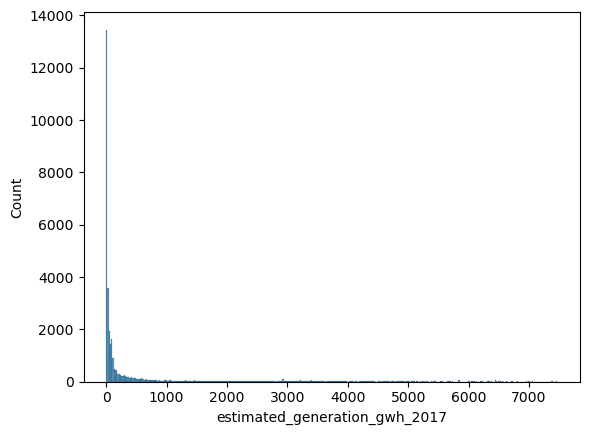

In [59]:
sns.histplot(df[df['estimated_generation_gwh_2017']<7500]['estimated_generation_gwh_2017'])

Vu que la variable ne suit pas une loi normale, il plus préférable de remplacer les valeurs manquantes de 'estimated_generation_gwh_2017' par la médiane 

In [61]:
df.iloc[:,8:-5].isnull().sum()

commissioning_year               17473
owner                            14052
source                               0
url                                  0
geolocation_source                   0
wepp_id                          18684
year_of_capacity_data            20031
generation_gwh_2013              28501
generation_gwh_2014              27692
generation_gwh_2015              26715
generation_gwh_2016              25774
generation_gwh_2017              25418
generation_gwh_2018              25281
generation_gwh_2019              25259
generation_data_source           23518
estimated_generation_gwh_2013    18801
estimated_generation_gwh_2014    18418
estimated_generation_gwh_2015    17871
estimated_generation_gwh_2016    17351
estimated_generation_gwh_2017        0
dtype: int64

In [60]:
df['estimated_generation_gwh_2017'] = df['estimated_generation_gwh_2017'].fillna(df['estimated_generation_gwh_2017'].median())

## **2. Exploratory Data Analysis:**

## **3. Statistical Analysis:**

## **4. Time Series Analysis:**

## **5. Advanced Visualization:**

## **6. Matrix Operations in Real-World Context:**

## **7. Integrating NumPy with Pandas and Matplotlib:**

In [46]:
7. 

7.0